# Pupil Size Outlier Removal: Expert Approach Comparison

This notebook compares multiple expert strategies for removing extreme pupil size outliers where left and right measurements are in severe disagreement (likely measurement errors).

**Workflow:**
1. Define multiple cleaning strategies (ratio-based, absolute difference, hybrid)
2. Apply all strategies and compare effectiveness vs data loss
3. Visualize the selected strategy (default: 1.5mm absolute difference) on critical subjects
4. Report overall improvement metrics

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import time
import seaborn as sns

In [2]:
def load_eseed_dataset(data_dir: str, cache=True, cached_filename="cached_eseed_dataset.csv") -> pd.DataFrame:
    """Load all CSV files from the processed eSEEd dataset."""
    start_time = time.time()
    if cache:
        cached_path = os.path.join(data_dir, "..", cached_filename)
        if os.path.exists(cached_path):
            print(f"Loading cached eSEEd dataset from {cached_path}...")
            return pd.read_csv(cached_path)
    df = pd.DataFrame()
    for csv_file in os.listdir(data_dir):
        if csv_file.endswith(".csv"):
            df_part = pd.read_csv(os.path.join(data_dir, csv_file))
            df = pd.concat([df, df_part], ignore_index=True)
    print(f"Loaded eSEEd dataset in {time.time() - start_time:.2f} seconds.")
    if cache:
        p = os.path.join(data_dir, "..", cached_filename)
        df.to_csv(p, index=False)
    return df


def compute_pupil_stats(df: pd.DataFrame) -> pd.DataFrame:
    """Compute pupil size comparison statistics per subject."""
    df_pupils = df[['subject', 'pupil-size-left-avg', 'pupil-size-right-avg']].dropna()
    
    stats_per_subject = []
    for subject in df_pupils['subject'].unique():
        left = df_pupils.loc[df_pupils['subject'] == subject, 'pupil-size-left-avg']
        right = df_pupils.loc[df_pupils['subject'] == subject, 'pupil-size-right-avg']
        
        stats_per_subject.append({
            'subject': subject,
            'n_samples': len(left),
            'corr': left.corr(right),
            'mae': np.abs(left - right).mean(),
            'rmse': np.sqrt(((left - right) ** 2).mean()),
            'max_diff': np.abs(left - right).max(),
            'mean_left': left.mean(),
            'mean_right': right.mean()
        })
    
    return pd.DataFrame(stats_per_subject).sort_values('mae', ascending=False)


def apply_cleaning_strategy(df: pd.DataFrame, strategy_name: str, criterion_fn) -> tuple:
    """
    Apply a cleaning strategy and return cleaned df + stats.
    
    Args:
        df: Original DataFrame
        strategy_name: Name of the strategy
        criterion_fn: Function that takes (left, right) arrays and returns outlier mask
        
    Returns:
        df_clean, removal_stats, improvement_stats
    """
    df_clean = df.copy()
    
    left = df_clean['pupil-size-left-avg'].values
    right = df_clean['pupil-size-right-avg'].values
    
    # Find valid points
    valid_mask = (left > MIN_VALID_PUPIL_SIZE) & (right > MIN_VALID_PUPIL_SIZE) & \
                 (~np.isnan(left)) & (~np.isnan(right))
    
    # Apply criterion to valid points
    outlier_mask = np.zeros(len(df_clean), dtype=bool)
    if valid_mask.any():
        outlier_mask[valid_mask] = criterion_fn(left[valid_mask], right[valid_mask])
    
    # Remove outliers
    df_clean.loc[outlier_mask, 'pupil-size-left-avg'] = np.nan
    df_clean.loc[outlier_mask, 'pupil-size-right-avg'] = np.nan
    
    # Compute statistics per subject
    stats = []
    for subject in df['subject'].unique():
        subject_mask = df['subject'] == subject
        initial_valid = valid_mask[subject_mask].sum()
        outliers_in_subject = outlier_mask[subject_mask].sum()
        
        pct_removed = (outliers_in_subject / initial_valid * 100) if initial_valid > 0 else 0
        
        stats.append({
            'subject': subject,
            'initial_valid': int(initial_valid),
            'outliers_removed': int(outliers_in_subject),
            'pct_removed': pct_removed,
            'remaining_valid': int(initial_valid - outliers_in_subject)
        })
    
    df_stats = pd.DataFrame(stats)
    
    # Compute improvement metrics
    stats_before = compute_pupil_stats(df)
    stats_after = compute_pupil_stats(df_clean)
    
    median_mae_before = stats_before['mae'].median()
    median_mae_after = stats_after['mae'].median()
    
    # Guard against division by zero
    if median_mae_before > 0:
        mae_improvement_pct = ((median_mae_before - median_mae_after) / median_mae_before) * 100
    else:
        mae_improvement_pct = 0.0
    
    improvement = {
        'strategy': strategy_name,
        'total_points_removed': int(outlier_mask.sum()),
        'pct_data_loss': (outlier_mask.sum() / valid_mask.sum()) * 100,
        'median_mae_before': median_mae_before,
        'median_mae_after': median_mae_after,
        'mae_improvement_pct': mae_improvement_pct,
        'median_corr_before': stats_before['corr'].median(),
        'median_corr_after': stats_after['corr'].median(),
        'subjects_mae_gt_0.5_before': (stats_before['mae'] > 0.5).sum(),
        'subjects_mae_gt_0.5_after': (stats_after['mae'] > 0.5).sum(),
    }
    
    return df_clean, df_stats, improvement

## Function Definitions

In [3]:
# Constants
DATA_DIR = "../../data/processed/eSEEd_v2_processed/"
MIN_VALID_PUPIL_SIZE = 0.1  # mm - minimum size to consider valid
MAX_VALID_PUPIL_SIZE = 8.0  # mm - maximum size to consider valid
N_CRITICAL_SUBJECTS = 48  # Number of worst subjects to visualize
DEFAULT_STRATEGY = 'abs_1.5mm'  # Default strategy to visualize in detail

## Configuration

## Load Dataset

In [4]:
# Load dataset
df = load_eseed_dataset(DATA_DIR)
print(f"Total rows: {len(df):,}")
print(f"Subjects: {df['subject'].nunique()}")
print(f"Recordings: {df['recording'].nunique()}")

Loading cached eSEEd dataset from ../../data/processed/eSEEd_v2_processed/../cached_eseed_dataset.csv...
Total rows: 3,423,045
Subjects: 48
Recordings: 10


In [5]:
# fill nans with the othereye's value if one is missing and the other is valid
df['pupil-size-left-avg'] = df['pupil-size-left-avg'].fillna(df['pupil-size-right-avg'])
df['pupil-size-right-avg'] = df['pupil-size-right-avg'].fillna(df['pupil-size-left-avg'])
# fill 0s with other eye's value if one is 0 and the other is valid
mask_left_zero = (df['pupil-size-left-avg'] == 0) & (df['pupil-size-right-avg'] > MIN_VALID_PUPIL_SIZE) & (df['pupil-size-right-avg'] < MAX_VALID_PUPIL_SIZE)
mask_right_zero = (df['pupil-size-right-avg'] == 0) & (df['pupil-size-left-avg'] > MIN_VALID_PUPIL_SIZE) & (df['pupil-size-left-avg'] < MAX_VALID_PUPIL_SIZE)

df.loc[mask_left_zero, 'pupil-size-left-avg'] = df.loc[mask_left_zero, 'pupil-size-right-avg']
df.loc[mask_right_zero, 'pupil-size-right-avg'] = df.loc[mask_right_zero, 'pupil-size-left-avg']

## Strategy Comparison: Test All Expert Approaches

In [6]:
# Define all expert strategies
strategies = {
    'ratio_2.0x': lambda l, r: np.maximum(l/r, r/l) > 2.0,
    'ratio_3.0x': lambda l, r: np.maximum(l/r, r/l) > 3.0,
    'abs_1.0mm': lambda l, r: np.abs(l - r) > 1.0,
    'abs_1.5mm': lambda l, r: np.abs(l - r) > 1.5,
    'abs_2.0mm': lambda l, r: np.abs(l - r) > 2.0,
    'hybrid_abs1.5_ratio2': lambda l, r: (np.abs(l - r) > 1.5) | (np.maximum(l/r, r/l) > 2.0),
    'hybrid_abs2_ratio2': lambda l, r: (np.abs(l - r) > 2.0) | (np.maximum(l/r, r/l) > 2.0),
    'hybrid_abs2_ratio3': lambda l, r: (np.abs(l - r) > 2.0) | (np.maximum(l/r, r/l) > 3.0),
}

# Apply each strategy and collect results
print("Applying all strategies...")
results = []
cleaned_dfs = {}

for name, criterion in strategies.items():
    print(f"  Testing: {name}...")
    df_clean, removal_stats, improvement = apply_cleaning_strategy(df, name, criterion)
    results.append(improvement)
    cleaned_dfs[name] = df_clean

# Create comparison DataFrame
df_comparison = pd.DataFrame(results)
df_comparison = df_comparison.sort_values('mae_improvement_pct', ascending=False)

print("\n" + "="*100)
print("STRATEGY COMPARISON RESULTS")
print("="*100)
print(df_comparison.to_string(index=False))

# Find best balance (good improvement, low data loss)
df_comparison['score'] = df_comparison['mae_improvement_pct'] / (df_comparison['pct_data_loss'] + 0.1)
best_balance_idx = df_comparison['score'].idxmax()

print("\n" + "="*100)
print("RECOMMENDATIONS:")
print("="*100)
print(f"\nBest MAE improvement: {df_comparison.iloc[0]['strategy']} "
      f"({df_comparison.iloc[0]['mae_improvement_pct']:.1f}% improvement)")
print(f"  → Removes {df_comparison.iloc[0]['pct_data_loss']:.2f}% of data")
print(f"  → MAE: {df_comparison.iloc[0]['median_mae_before']:.4f} → "
      f"{df_comparison.iloc[0]['median_mae_after']:.4f} mm")

print(f"\nBest balance (improvement/data_loss): {df_comparison.loc[best_balance_idx, 'strategy']}")
print(f"  → Removes {df_comparison.loc[best_balance_idx, 'pct_data_loss']:.2f}% of data")
print(f"  → MAE improvement: {df_comparison.loc[best_balance_idx, 'mae_improvement_pct']:.1f}%")

Applying all strategies...
  Testing: ratio_2.0x...
  Testing: ratio_3.0x...
  Testing: abs_1.0mm...
  Testing: abs_1.5mm...
  Testing: abs_2.0mm...
  Testing: hybrid_abs1.5_ratio2...
  Testing: hybrid_abs2_ratio2...
  Testing: hybrid_abs2_ratio3...

STRATEGY COMPARISON RESULTS
            strategy  total_points_removed  pct_data_loss  median_mae_before  median_mae_after  mae_improvement_pct  median_corr_before  median_corr_after  subjects_mae_gt_0.5_before  subjects_mae_gt_0.5_after
           abs_1.0mm                321581       9.541916           0.377007          0.321957            14.601874            0.617325           0.726608                          15                          5
hybrid_abs1.5_ratio2                132033       3.917669           0.377007          0.339487             9.952011            0.617325           0.688735                          15                         12
           abs_1.5mm                130993       3.886810           0.377007          0.339

## Visualize Strategy Comparison

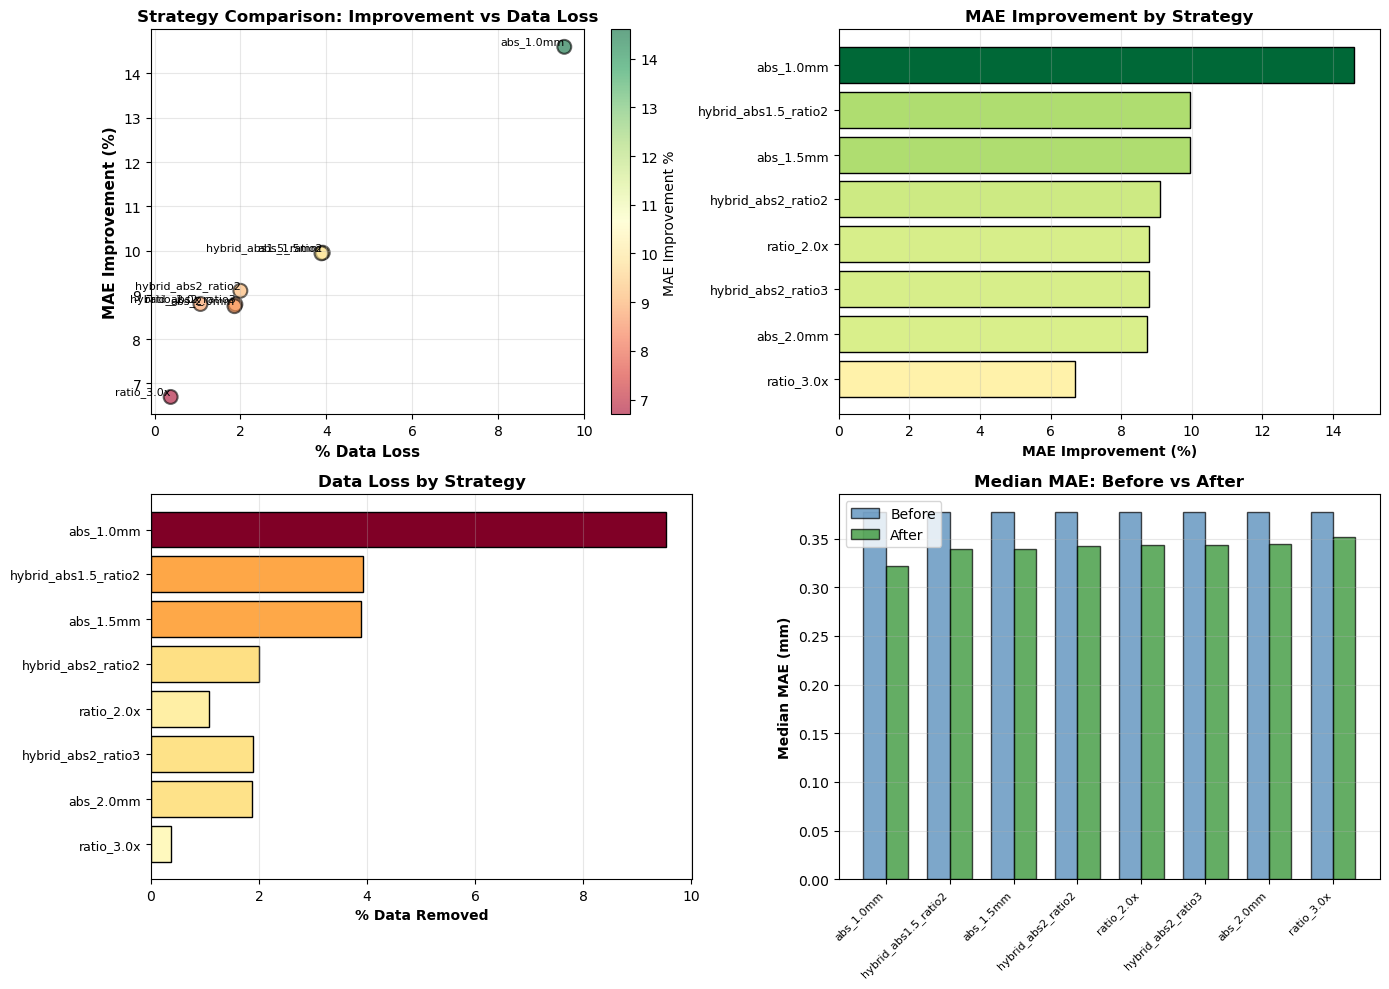

In [7]:
# Visualize strategy comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: MAE improvement vs Data loss (scatter)
ax = axes[0, 0]
scatter = ax.scatter(df_comparison['pct_data_loss'], 
                    df_comparison['mae_improvement_pct'],
                    s=100, alpha=0.6, c=df_comparison['mae_improvement_pct'], 
                    cmap='RdYlGn', edgecolors='black', linewidth=1.5)
for idx, row in df_comparison.iterrows():
    ax.annotate(row['strategy'], 
               (row['pct_data_loss'], row['mae_improvement_pct']),
               fontsize=8, ha='right', va='bottom')
ax.set_xlabel('% Data Loss', fontweight='bold', fontsize=11)
ax.set_ylabel('MAE Improvement (%)', fontweight='bold', fontsize=11)
ax.set_title('Strategy Comparison: Improvement vs Data Loss', fontweight='bold', fontsize=12)
ax.grid(alpha=0.3)
plt.colorbar(scatter, ax=ax, label='MAE Improvement %')

# Plot 2: Bar chart of MAE improvement
ax = axes[0, 1]
bars = ax.barh(range(len(df_comparison)), df_comparison['mae_improvement_pct'], 
               color=plt.cm.RdYlGn(df_comparison['mae_improvement_pct'] / 
                                   df_comparison['mae_improvement_pct'].max()),
               edgecolor='black', linewidth=1)
ax.set_yticks(range(len(df_comparison)))
ax.set_yticklabels(df_comparison['strategy'], fontsize=9)
ax.set_xlabel('MAE Improvement (%)', fontweight='bold')
ax.set_title('MAE Improvement by Strategy', fontweight='bold', fontsize=12)
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()

# Plot 3: Data loss comparison
ax = axes[1, 0]
bars = ax.barh(range(len(df_comparison)), df_comparison['pct_data_loss'],
               color=plt.cm.YlOrRd(df_comparison['pct_data_loss'] / 
                                   df_comparison['pct_data_loss'].max()),
               edgecolor='black', linewidth=1)
ax.set_yticks(range(len(df_comparison)))
ax.set_yticklabels(df_comparison['strategy'], fontsize=9)
ax.set_xlabel('% Data Removed', fontweight='bold')
ax.set_title('Data Loss by Strategy', fontweight='bold', fontsize=12)
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()

# Plot 4: Before/After MAE comparison
ax = axes[1, 1]
x = np.arange(len(df_comparison))
width = 0.35
bars1 = ax.bar(x - width/2, df_comparison['median_mae_before'], width, 
              label='Before', alpha=0.7, color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, df_comparison['median_mae_after'], width,
              label='After', alpha=0.7, color='forestgreen', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(df_comparison['strategy'], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Median MAE (mm)', fontweight='bold')
ax.set_title('Median MAE: Before vs After', fontweight='bold', fontsize=12)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Detailed Visualization: Selected Strategy

Show before/after scatter plots for the most critical subjects using the selected strategy.

In [ ]:
# Use the default selected strategy
selected_strategy = DEFAULT_STRATEGY
df_selected_cleaned = cleaned_dfs[selected_strategy]

print(f"Visualizing strategy: {selected_strategy}")

# Get the selected strategy's stats
selected_stats = df_comparison[df_comparison['strategy'] == selected_strategy].iloc[0]
print(f"  MAE improvement: {selected_stats['mae_improvement_pct']:.1f}%")
print(f"  Data loss: {selected_stats['pct_data_loss']:.2f}%")
print(f"  Median MAE: {selected_stats['median_mae_before']:.4f} → "
      f"{selected_stats['median_mae_after']:.4f} mm")

# Compute stats for visualization
stats_original = compute_pupil_stats(df)
stats_cleaned = compute_pupil_stats(df_selected_cleaned)

# Get critical subjects (worst MAE in original data)
critical_subjects = stats_original.head(N_CRITICAL_SUBJECTS)['subject'].values

# Create before/after comparison plots
fig, axes = plt.subplots(N_CRITICAL_SUBJECTS, 2, figsize=(12, 3*N_CRITICAL_SUBJECTS))

for idx, subject in enumerate(critical_subjects):
    # BEFORE (left column)
    df_subj_orig = df[df['subject'] == subject][['pupil-size-left-avg', 
                                                   'pupil-size-right-avg']].dropna()
    left_orig = df_subj_orig['pupil-size-left-avg']
    right_orig = df_subj_orig['pupil-size-right-avg']
    
    ax_before = axes[idx, 0]
    ax_before.scatter(left_orig, right_orig, alpha=0.5, s=15, color='steelblue', 
                     edgecolors='black', linewidth=0.3)
    
    # Perfect agreement line
    min_val = min(left_orig.min(), right_orig.min())
    max_val = max(left_orig.max(), right_orig.max())
    ax_before.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, 
                  label='Perfect Agreement')
    
    # Statistics
    stats_orig = stats_original[stats_original['subject'] == subject].iloc[0]
    ax_before.set_title(f"BEFORE - Subject {subject}\n"
                       f"MAE={stats_orig['mae']:.3f}mm, Corr={stats_orig['corr']:.3f}, "
                       f"N={len(left_orig)}", 
                       fontsize=9, fontweight='bold')
    ax_before.set_xlabel('Left Pupil Size (mm)', fontsize=8)
    ax_before.set_ylabel('Right Pupil Size (mm)', fontsize=8)
    ax_before.legend(loc='upper left', fontsize=7)
    ax_before.grid(alpha=0.3)
    ax_before.axis('equal')
    ax_before.set_xlim(min_val - 0.5, max_val + 0.5)
    ax_before.set_ylim(min_val - 0.5, max_val + 0.5)
    
    # AFTER (right column)
    df_subj_clean = df_selected_cleaned[df_selected_cleaned['subject'] == subject][
        ['pupil-size-left-avg', 'pupil-size-right-avg']].dropna()
    left_clean = df_subj_clean['pupil-size-left-avg']
    right_clean = df_subj_clean['pupil-size-right-avg']
    
    ax_after = axes[idx, 1]
    
    if len(left_clean) > 0:
        ax_after.scatter(left_clean, right_clean, alpha=0.5, s=15, color='forestgreen', 
                        edgecolors='black', linewidth=0.3)
        
        # Perfect agreement line
        min_val_clean = min(left_clean.min(), right_clean.min())
        max_val_clean = max(left_clean.max(), right_clean.max())
        ax_after.plot([min_val_clean, max_val_clean], [min_val_clean, max_val_clean], 
                     'r--', linewidth=2, label='Perfect Agreement')
        
        # Statistics
        stats_clean = stats_cleaned[stats_cleaned['subject'] == subject].iloc[0]
        n_removed = len(left_orig) - len(left_clean)
        pct_removed = (n_removed / len(left_orig)) * 100 if len(left_orig) > 0 else 0
        ax_after.set_title(f"AFTER - Subject {subject}\n"
                          f"MAE={stats_clean['mae']:.3f}mm, Corr={stats_clean['corr']:.3f}, "
                          f"N={len(left_clean)}\n"
                          f"Removed: {n_removed} ({pct_removed:.1f}%)", 
                          fontsize=9, fontweight='bold', color='darkgreen')
        ax_after.set_xlim(min_val_clean - 0.5, max_val_clean + 0.5)
        ax_after.set_ylim(min_val_clean - 0.5, max_val_clean + 0.5)
    else:
        ax_after.set_title(f"AFTER - Subject {subject}\nNo valid data remaining", 
                          fontsize=9, fontweight='bold', color='red')
    
    ax_after.set_xlabel('Left Pupil Size (mm)', fontsize=8)
    ax_after.set_ylabel('Right Pupil Size (mm)', fontsize=8)
    ax_after.legend(loc='upper left', fontsize=7)
    ax_after.grid(alpha=0.3)
    ax_after.axis('equal')

plt.suptitle(f'Strategy: {selected_strategy} - Before vs After Cleaning', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
os.makedirs('./plots-EDA', exist_ok=True)
plt.savefig(f'./plots-EDA/pupil_cleaning_comparison_{selected_strategy}.png', dpi=300)
# plt.show()
plt.close()

Visualizing strategy: abs_1.5mm
  MAE improvement: 9.9%
  Data loss: 3.89%
  Median MAE: 0.3770 → 0.3395 mm


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x

### Overall Improvement Summary

In [9]:
# Print overall improvement for selected strategy
print("\n" + "="*100)
print(f"OVERALL IMPROVEMENT: {selected_strategy}")
print("="*100)

print(f"\nMedian MAE:")
print(f"  Before: {selected_stats['median_mae_before']:.4f} mm")
print(f"  After:  {selected_stats['median_mae_after']:.4f} mm")
print(f"  Improvement: {selected_stats['mae_improvement_pct']:.1f}%")

print(f"\nMedian Correlation:")
print(f"  Before: {selected_stats['median_corr_before']:.4f}")
print(f"  After:  {selected_stats['median_corr_after']:.4f}")
improvement_corr = ((selected_stats['median_corr_after'] - selected_stats['median_corr_before']) / 
                   (1 - selected_stats['median_corr_before'])) * 100
print(f"  Improvement: {improvement_corr:.1f}%")

print(f"\nSubjects with MAE > 0.5 mm:")
print(f"  Before: {int(selected_stats['subjects_mae_gt_0.5_before'])}")
print(f"  After:  {int(selected_stats['subjects_mae_gt_0.5_after'])}")

print(f"\nData Loss:")
print(f"  Points removed: {int(selected_stats['total_points_removed']):,}")
print(f"  Percentage: {selected_stats['pct_data_loss']:.2f}%")

print("\n" + "="*100)
print(f"Cleaned data available in: cleaned_dfs['{selected_strategy}']")
print("="*100)


OVERALL IMPROVEMENT: abs_1.5mm

Median MAE:
  Before: 0.3770 mm
  After:  0.3395 mm
  Improvement: 9.9%

Median Correlation:
  Before: 0.6173
  After:  0.6897
  Improvement: 18.9%

Subjects with MAE > 0.5 mm:
  Before: 15
  After:  12

Data Loss:
  Points removed: 130,993
  Percentage: 3.89%

Cleaned data available in: cleaned_dfs['abs_1.5mm']


In [10]:
BAD_PUPIL_SUBJECTS = stats_original[stats_original['mae'] > 0.5]['subject'].tolist()
print(f"\nSubjects with MAE > 0.5 mm in original data: {len(BAD_PUPIL_SUBJECTS)}")
print(f"Subject IDs: {BAD_PUPIL_SUBJECTS}")


Subjects with MAE > 0.5 mm in original data: 15
Subject IDs: [13, 36, 8, 5, 39, 15, 6, 31, 37, 40, 24, 34, 16, 48, 17]


In [11]:
# drop bad pupil subjects and save the cleaned dataset to data_dir/eSEEd_v2_cleaned/eSEEd_pupil_cleaned.csv
df_final_cleaned = df_selected_cleaned[~df_selected_cleaned['subject'].isin(BAD_PUPIL_SUBJECTS)]
output_dir = os.path.join(DATA_DIR, "..", "eSEEd_v2_cleaned")
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "eSEEd_pupil_cleaned.csv")
df_final_cleaned.to_csv(output_path, index=False)
print(f"\nFinal cleaned dataset saved to: {output_path}")


Final cleaned dataset saved to: ../../data/processed/eSEEd_v2_processed/../eSEEd_v2_cleaned/eSEEd_pupil_cleaned.csv
